# Statistical Methods in Imaging (SMI) Conference, 2026.
# Empowering Large Language Models with Statistics: A Practical Tutorial for Medical Imaging
**Ernest (Khashayar) Namdar, Dominik A. Deniffel, Pascal Tyrrell**

This tutorial focuses on classifying Acute Ischemic Stroke (AIS) from Radiology reports. We will use the `Label` and `Text` columns for a binary classification task.

Several similar pipelines were discussed in our publication:
```bibtex
@inproceedings{10.1117/12.3084682,
author = {Khashayar Namdar and Saeidehsadat Mirjalili and Lauren Erdman and Dominik A. Deniffel and Keith Brunt and Leo Anthony Celi},
title = {{Comparative evaluation of machine learning and large language model pipelines for identifying acute ischemic stroke in radiology reports}},
volume = {13926},
booktitle = {Medical Imaging 2026: Computer-Aided Diagnosis},
editor = {Axel Wism{\"u}ller and Thomas Martin Deserno},
organization = {International Society for Optics and Photonics},
publisher = {SPIE},
pages = {139261S},
keywords = {Stroke, NLP, Machine Learning, Large Language Models},
year = {2026},
doi = {10.1117/12.3084682},
URL = {https://doi.org/10.1117/12.3084682}
}
```

Also, the source for the dataset is:
```bibtex
@article{10.1371/journal.pone.0212778,
    doi = {10.1371/journal.pone.0212778},
    author = {Kim, Chulho AND Zhu, Vivienne AND Obeid, Jihad AND Lenert, Leslie},
    journal = {PLOS ONE},
    publisher = {Public Library of Science},
    title = {Natural language processing and machine learning algorithm to identify brain MRI reports with acute ischemic stroke},
    year = {2019},
    month = {02},
    volume = {14},
    url = {https://doi.org/10.1371/journal.pone.0212778},
    pages = {1-13},
    number = {2},
}
```


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the dataset
data_path = '../data/AIS.csv'
try:
    df = pd.read_csv(data_path)
    print(f"Dataset loaded successfully with {len(df)} records.")
except FileNotFoundError:
    print(f"Error: Could not find the dataset at {data_path}")

Dataset loaded successfully with 3024 records.


## Exploratory Data Analysis (EDA)
Let's look at the distribution of the classes (0: Non-AIS, 1: AIS).

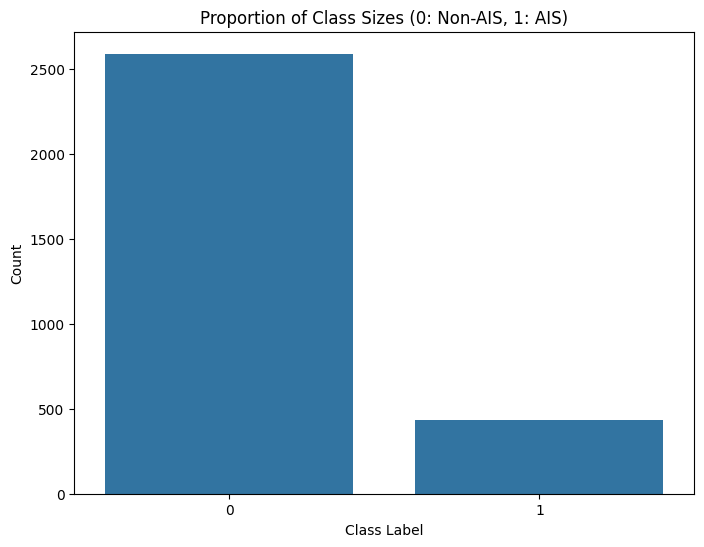

Class Proportions:
Label
0    0.857143
1    0.142857
Name: proportion, dtype: float64


In [4]:
# Plot proportions of class sizes
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=df)
plt.title('Proportion of Class Sizes (0: Non-AIS, 1: AIS)')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

# Display exact proportions
print("Class Proportions:")
print(df['Label'].value_counts(normalize=True))

## Example Record
Let's view an example of the text data and its corresponding label.

In [6]:
# Show an example
if not df.empty:
    # Displaying the first sample as an example
    sample = df.iloc[0]
    print(f"Label: {sample['Label']}\n")
    print(f"Text:\n{sample['Text']}")

Label: 0

Text:
1. No diffusion restriction in brain parenchyma.
2. Multiple calvarial mass in left fronto-parietal and right parietal area.
; Diffusion restriction  positive, about 6.4 cm in left, 3.3 cm in right, T1 and T2 low signal intensity, enhancement  positive, epidural extension positive.
3. magnetic resonance angiography; Multiple prominent left external carotid artery branches.
- supplied to left calvarial mass.

impression) Multiple calvarial metastasis.
       ; high malignancy or have high cellular component


## BioClinical ModernBERT
We will use `thomas-sounack/BioClinical-ModernBERT-base` to extract embeddings for the radiology reports. First, let's test the Masked Language Modeling capabilities of this model.

In [8]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

model_id = "thomas-sounack/BioClinical-ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForMaskedLM.from_pretrained(model_id)

text = "Mitochondria is the powerhouse of the [MASK]."
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)

# To get predictions for the mask:
masked_index = inputs["input_ids"][0].tolist().index(tokenizer.mask_token_id)
predicted_token_id = outputs.logits[0, masked_index].argmax(axis=-1)
predicted_token = tokenizer.decode(predicted_token_id)
print("Predicted token:", predicted_token)
# Predicted token:  cell

Loading weights:   0%|          | 0/137 [00:00<?, ?it/s]

Predicted token:  cell


### Extracting Embeddings
Now we will extract the sentence embeddings for the text column in our dataset and save them to `Embeddings.csv`. We will use mean pooling on the hidden states of the model.

In [10]:
import torch
from transformers import AutoModel
from tqdm import tqdm
import numpy as np
import pandas as pd

# Load the base model for embeddings
embed_model = AutoModel.from_pretrained(model_id)
embed_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embed_model.to(device)

print(f"Using device: {device}")

embeddings = []
texts = df['Text'].tolist()
batch_size = 16

print(f"Extracting embeddings for {len(texts)} reports...")
for i in tqdm(range(0, len(texts), batch_size)):
    batch_texts = texts[i:i+batch_size]
    # Truncate to 512 tokens to save memory and processing time
    inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = embed_model(**inputs)
        # Mean pooling over token embeddings, ignoring padding tokens
        attention_mask = inputs['attention_mask']
        token_embeddings = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        batch_embeddings = sum_embeddings / sum_mask
        
        embeddings.extend(batch_embeddings.cpu().numpy())

# Create a DataFrame and save it
emb_df = pd.DataFrame(embeddings)
emb_df.insert(0, 'ID', df['ID'].tolist())

output_path = '../data/Embeddings.csv'
emb_df.to_csv(output_path, index=False)
print(f"Embeddings saved to {output_path}")

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: thomas-sounack/BioClinical-ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cuda
Extracting embeddings for 3024 reports...


100%|██████████| 189/189 [00:06<00:00, 29.07it/s]


Embeddings saved to ../data/Embeddings.csv
